In [122]:
pip install cmdstanpy


[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [123]:

import cmdstanpy
import numpy as np
import pandas as pd 

In [124]:
df = pd.read_csv("forstmann.csv")
df["correct"] = df.apply(lambda row: 1 if row["S"] == row["R"] else 0,axis = 1)
df['participant_id'], participant_labels = pd.factorize(df['subjects'])
df['participant_id'] += 1  
sat_map = {"speed":1,"neutral":2,"accuracy":3}
df["sat_int"] = df["E"].map(sat_map)
df["pc"] = (df["participant_id"]-1)*3 + df["sat_int"]
df

,subjects,E,S,R,rt,correct,participant_id,sat_int,pc
0,as1t,accuracy,right,right,0.4319,1,1,3,3
1,as1t,speed,right,right,0.5015,1,1,1,1
2,as1t,speed,left,left,0.3104,1,1,1,1
3,as1t,accuracy,right,right,0.4809,1,1,3,3
4,as1t,accuracy,left,left,0.3415,1,1,3,3
...,...,...,...,...,...,...,...,...,...
15813,zk1t,speed,right,right,0.3244,1,19,1,55
15814,zk1t,neutral,left,left,0.5800,1,19,2,56
15815,zk1t,neutral,left,left,0.9199,1,19,2,56
15816,zk1t,accuracy,left,right,0.6314,0,19,3,57


In [125]:
min(rt_false)

0.2508

In [126]:
max_rt = (df.groupby(['participant_id','sat_int'])["rt"].max())
max_rt

participant_id  sat_int
1               1          0.7979
                2          1.1555
                3          0.9912
2               1          0.6489
                2          1.1242
                3          1.3960
3               1          0.8129
                2          1.4322
                3          1.4769
4               1          0.7022
                2          0.8110
                3          1.0007
5               1          0.6481
                2          0.9952
                3          1.4364
6               1          0.9039
                2          0.9092
                3          1.3001
7               1          1.2651
                2          1.2043
                3          1.4077
8               1          1.2592
                2          1.3809
                3          1.3834
9               1          1.3234
                2          1.1941
                3          1.2196
10              1          0.8278
                2       

In [127]:
N_correct = len(df[df["correct"] == 1])
N_false = len(df[df["correct"] == 0])
P = 19 
rt_correct = list(df[df["correct"]==1]["rt"])
rt_false = list(df[df["correct"]==0]["rt"])
pc_correct = list(df[df["correct"]==1]["pc"])
pc_false = list(df[df["correct"]==0]["pc"])



print(N_correct,N_false,rt_false)
data = {"N_correct":N_correct,"N_false":N_false,"P":P,
        "rt_correct":rt_correct,"rt_false":rt_false,
        "pc_correct":pc_correct,"pc_false":pc_false,"max_rt":max_rt}

from cmdstanpy import CmdStanModel

model = CmdStanModel(stan_file='SRDMlapse_fixed1.stan')





15:27:57 - cmdstanpy - INFO - compiling stan file /Users/Anton/Documents/ForskningsprojektSommer2026/ForstmannFit/SRDMlapse_fixed1.stan to exe file /Users/Anton/Documents/ForskningsprojektSommer2026/ForstmannFit/SRDMlapse_fixed1


13294 2524 [0.3111, 0.4118, 0.4343, 0.3286, 0.4872, 0.321, 0.4179, 0.6087, 0.3561, 0.5971, 0.4731, 0.7205, 0.4949, 0.4222, 0.3304, 0.5636, 0.2693, 0.2952, 0.3923, 0.4207, 0.3172, 0.3472, 0.4619, 0.5878, 0.4227, 0.4178, 0.7814, 0.4248, 0.4782, 0.2508, 0.3542, 0.2742, 0.4646, 0.5855, 0.4592, 0.5876, 0.4358, 0.3632, 0.5256, 0.6568, 0.6033, 0.5813, 0.3321, 0.6356, 0.3355, 0.6077, 0.6896, 0.4748, 0.4662, 0.5469, 0.4984, 0.3845, 0.4819, 0.4135, 0.4852, 0.4698, 0.4768, 0.4402, 0.6428, 0.4315, 0.6628, 0.7461, 0.4767, 0.5287, 0.6025, 0.5145, 0.8565, 0.4453, 0.5473, 0.4656, 0.4555, 0.6289, 0.3824, 0.4643, 0.485, 0.301, 0.3467, 0.4999, 0.3045, 0.5888, 0.5423, 0.4593, 0.5522, 0.4058, 0.5459, 0.4679, 0.6829, 0.4227, 0.6181, 0.4917, 0.3587, 0.3434, 0.5736, 0.388, 0.4163, 0.6115, 0.4535, 0.4528, 0.3136, 0.3105, 0.3589, 0.3007, 0.3154, 0.2692, 0.449, 0.3353, 0.3959, 0.4254, 0.4713, 0.5634, 0.3659, 0.369, 0.4745, 0.4393, 0.4981, 0.3239, 0.7392, 0.4319, 0.3065, 0.433, 0.6091, 0.3335, 0.5856, 0.4238, 0.2

15:28:17 - cmdstanpy - INFO - compiled model executable: /Users/Anton/Documents/ForskningsprojektSommer2026/ForstmannFit/SRDMlapse_fixed1


In [130]:


init_values = {
    'c': [0.0] * (3 * P),
    't0': [0.2] * (3 * P),      # matches your t0 prior mean
    'd': [1.0] * P,              # matches your d prior mean
    'r': [4.5] * P,              # comfortably above the 0.05 floor
    'B': [1.0] * P,
    'p_lapse': [0.05] * P,       # matches the beta(1,10) prior's rough mean
}

fit = model.sample(data=data,chains = 4, parallel_chains=4, inits=init_values,show_console=True)



15:28:53 - cmdstanpy - INFO - Chain [1] start processing
15:28:53 - cmdstanpy - INFO - Chain [2] start processing
15:28:53 - cmdstanpy - INFO - Chain [3] start processing
15:28:53 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 1000 (Default)
Chain [1] save_warmup = false (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = true (Default)
Chain [1] gamma = 0.05 (Default)
Chain [1] delta = 0.8 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] save_metric = false (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /var/folders/g5/d_krhx3n0xg4nf8x8frstwdw0000gq/T/tmp48lu7ilt/uyqr1ktj.json
Chain [1] init = /var/folders/g

16:03:47 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] 
Chain [3] Elapsed Time: 349.918 seconds (Warm-up)
Chain [3] 1743.36 seconds (Sampling)
Chain [3] 2093.28 seconds (Total)
Chain [3] 
Chain [3] 
Chain [1] Iteration: 1300 / 2000 [ 65%]  (Sampling)
Chain [4] Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain [1] Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain [4] Iteration: 1900 / 2000 [ 95%]  (Sampling)


16:10:10 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] Iteration: 2000 / 2000 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 1153.36 seconds (Warm-up)
Chain [4] 1322.95 seconds (Sampling)
Chain [4] 2476.31 seconds (Total)
Chain [4] 
Chain [4] 
Chain [1] Iteration: 1500 / 2000 [ 75%]  (Sampling)
Chain [1] Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain [1] Iteration: 1700 / 2000 [ 85%]  (Sampling)
Chain [1] Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain [1] Iteration: 1900 / 2000 [ 95%]  (Sampling)
Chain [2] Iteration: 1200 / 2000 [ 60%]  (Sampling)


16:23:29 - cmdstanpy - INFO - Chain [1] done processing
16:23:29 - cmdstanpy - INFO - Chain [2] done processing
16:23:29 - cmdstanpy - ERROR - Chain [1] error: terminated by signal 2 Unknown error: -2
16:23:29 - cmdstanpy - ERROR - Chain [2] error: terminated by signal 2 Unknown error: -2


Chain [1] Chain [2] 



KeyboardInterrupt: 

In [ ]:
import numpy as np
from scipy.stats import norm

t, B, vk, sigma_k = 0.3, 1.0, 0.3, 0.05  # plug in something near your priors' means
f_diffusion = B / (sigma_k * np.sqrt(2*np.pi*t**3)) * np.exp(-(B - vk*t)**2 / (2*sigma_k**2*t))
lapse_density = 1 / 1.5  # 1/max_rt, guessing a plausible max_rt

print(f_diffusion, lapse_density)

8.447947443336028e-239 0.6666666666666666


In [ ]:
pip install arviz

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/arviz/plots/backends/matplotlib/pairplot.py:233: UserWarning: rcParams['plot.max_subplots'] (40) is smaller than the number of resulting pair plots with these variables, generating only a 8x8 grid
  warnings.warn(


array([[<Axes: ylabel='t0\n1'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='t0\n2'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='t0\n3'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='t0\n4'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='t0\n5'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='t0\n6'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: ylabel='t0\n7'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
        <Axes: >, <Axes: >, <Axes: >],
       [<Axes: xlabel='t0\n0', ylabel='t0\n8'>, <Axes: xlabel='t0\n1'>,
        <Axes: xlabel='t0\n2'>, <Axes: xlabel='t0\n3'>,
        <Axes: xlabel='t0\n4'>, <Axes: xlabel='t0\n5'>,
        <Axes: xlabel='t0\n6'>, <Axes: 

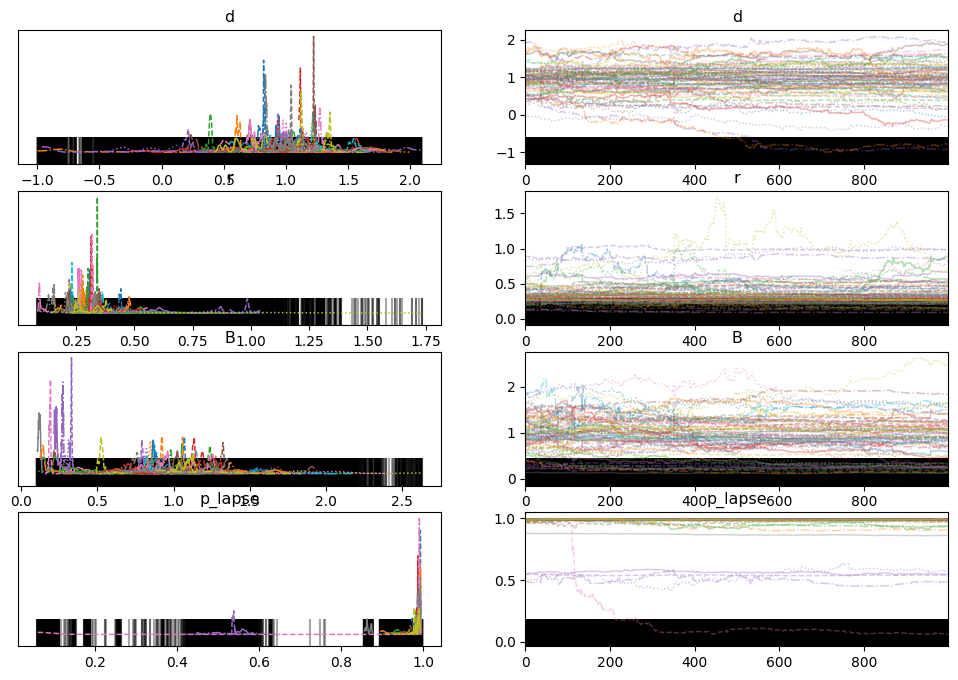

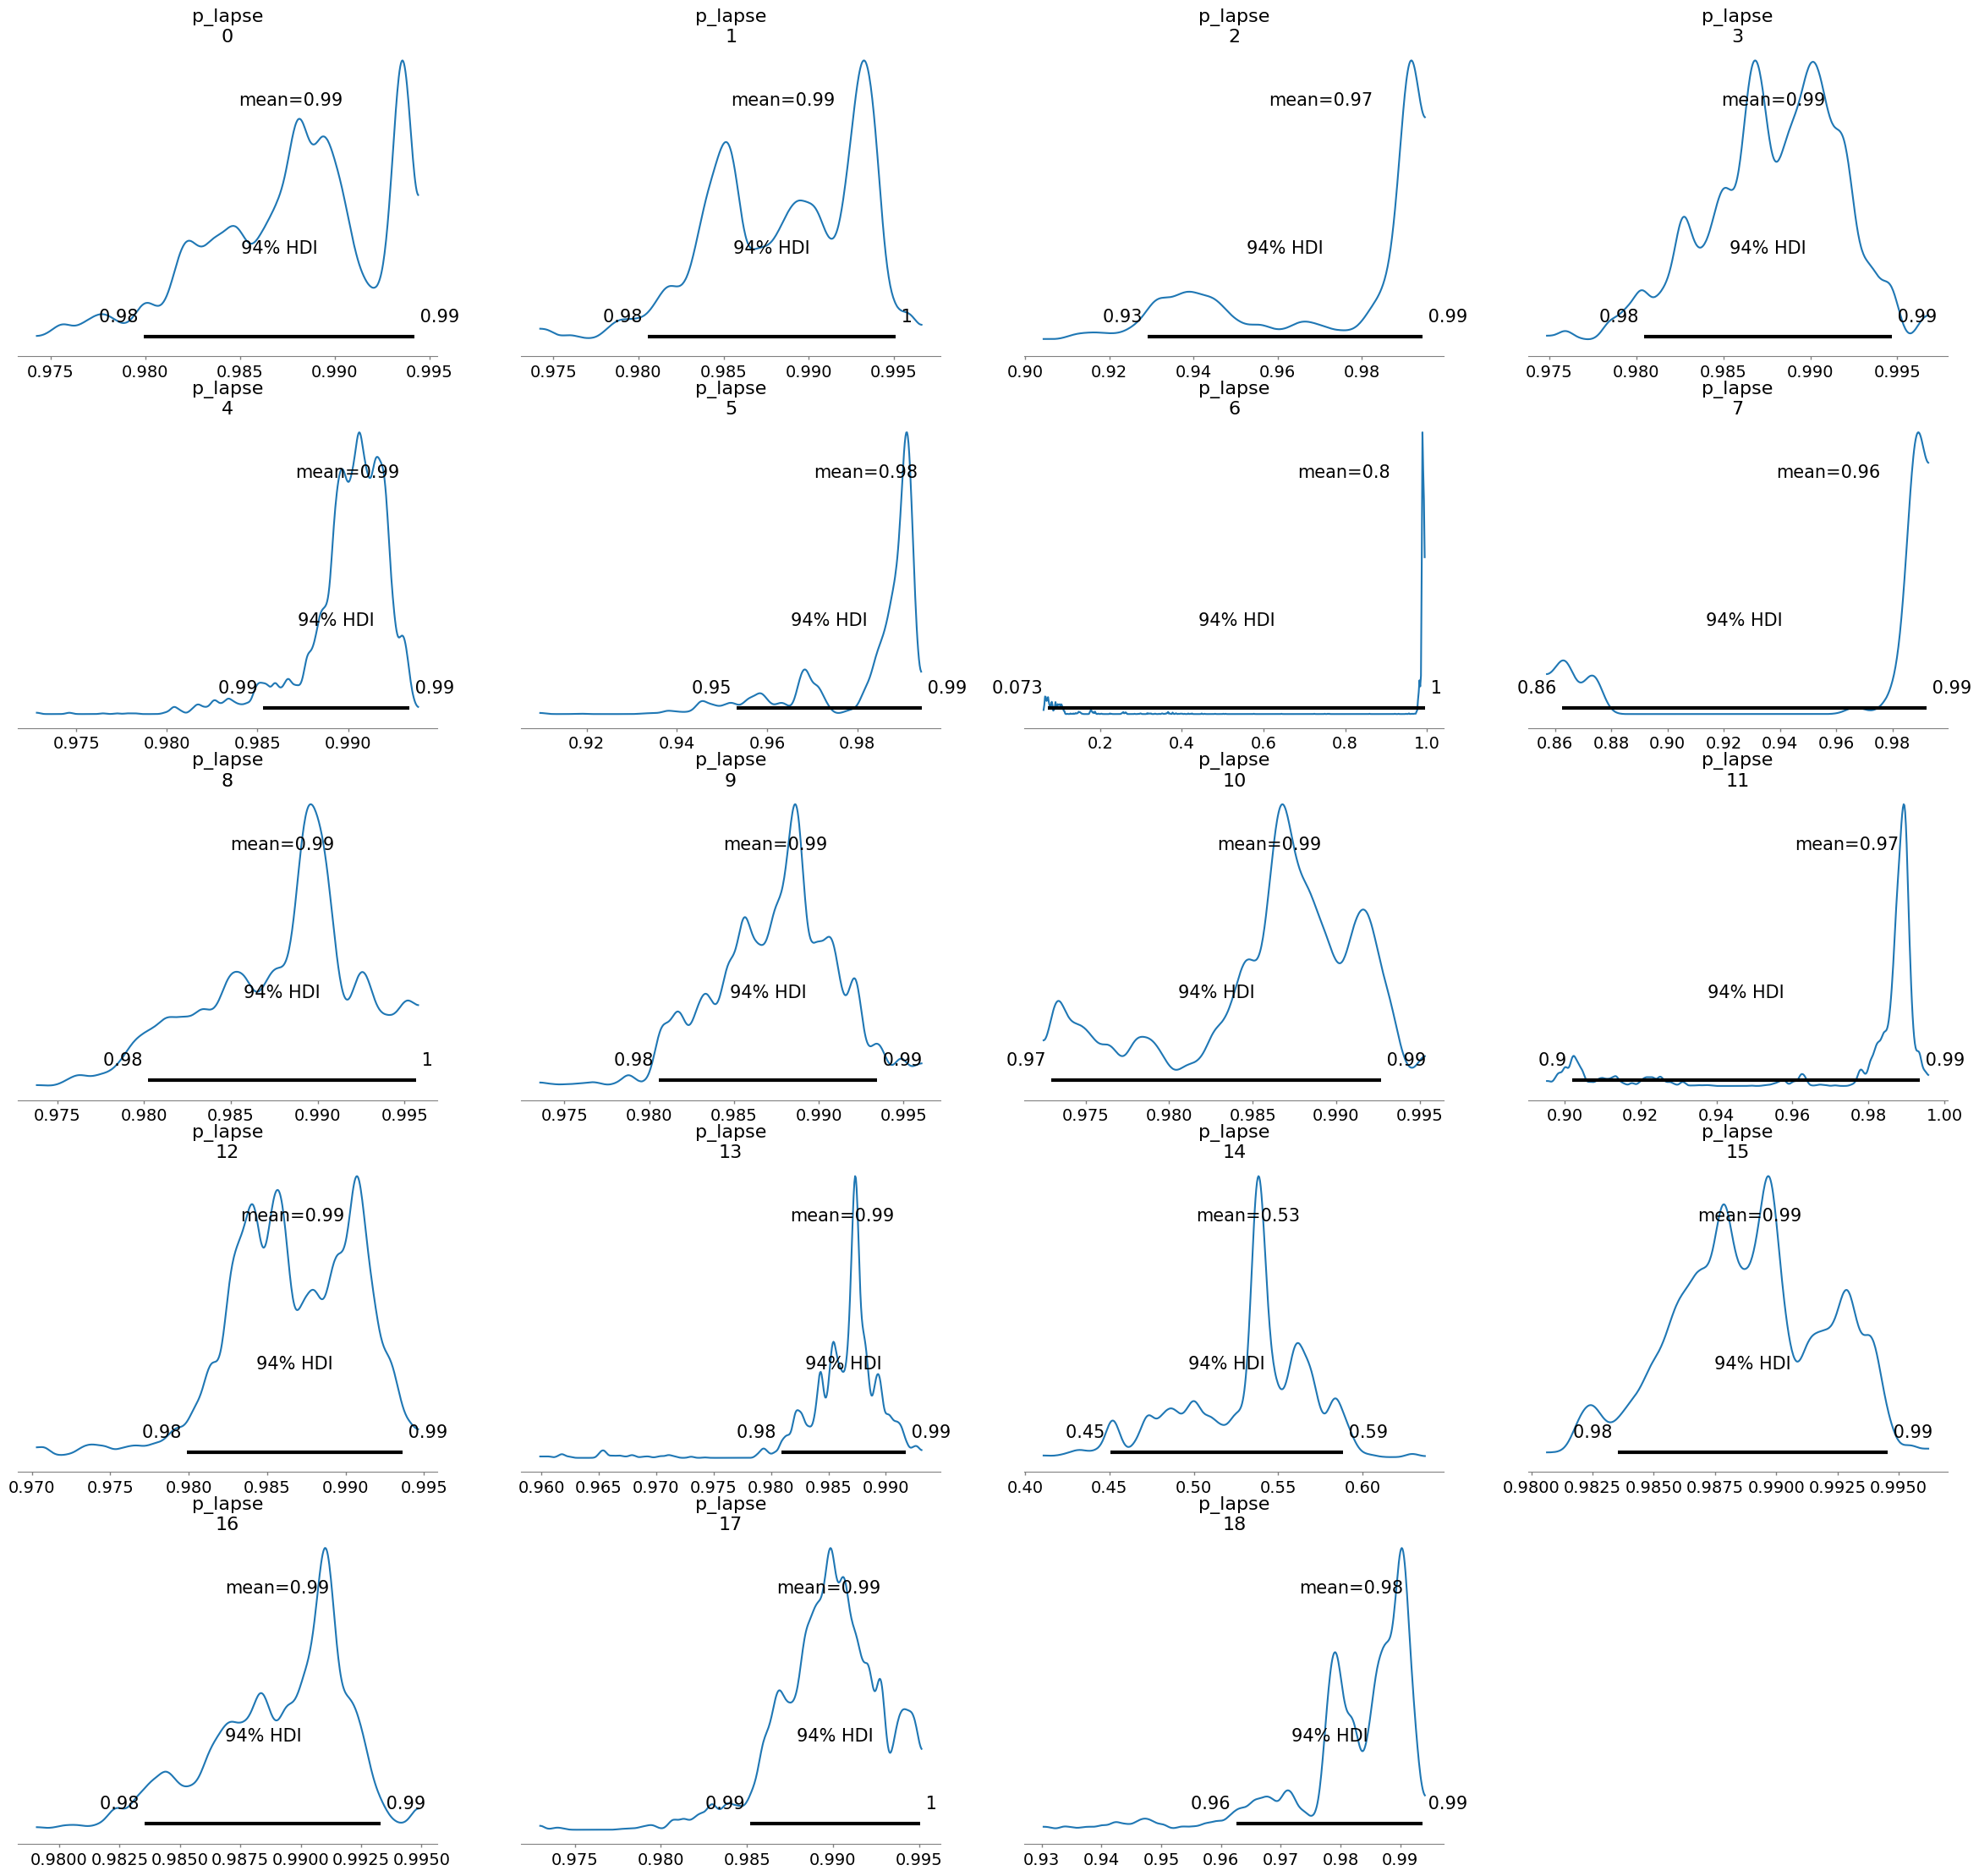

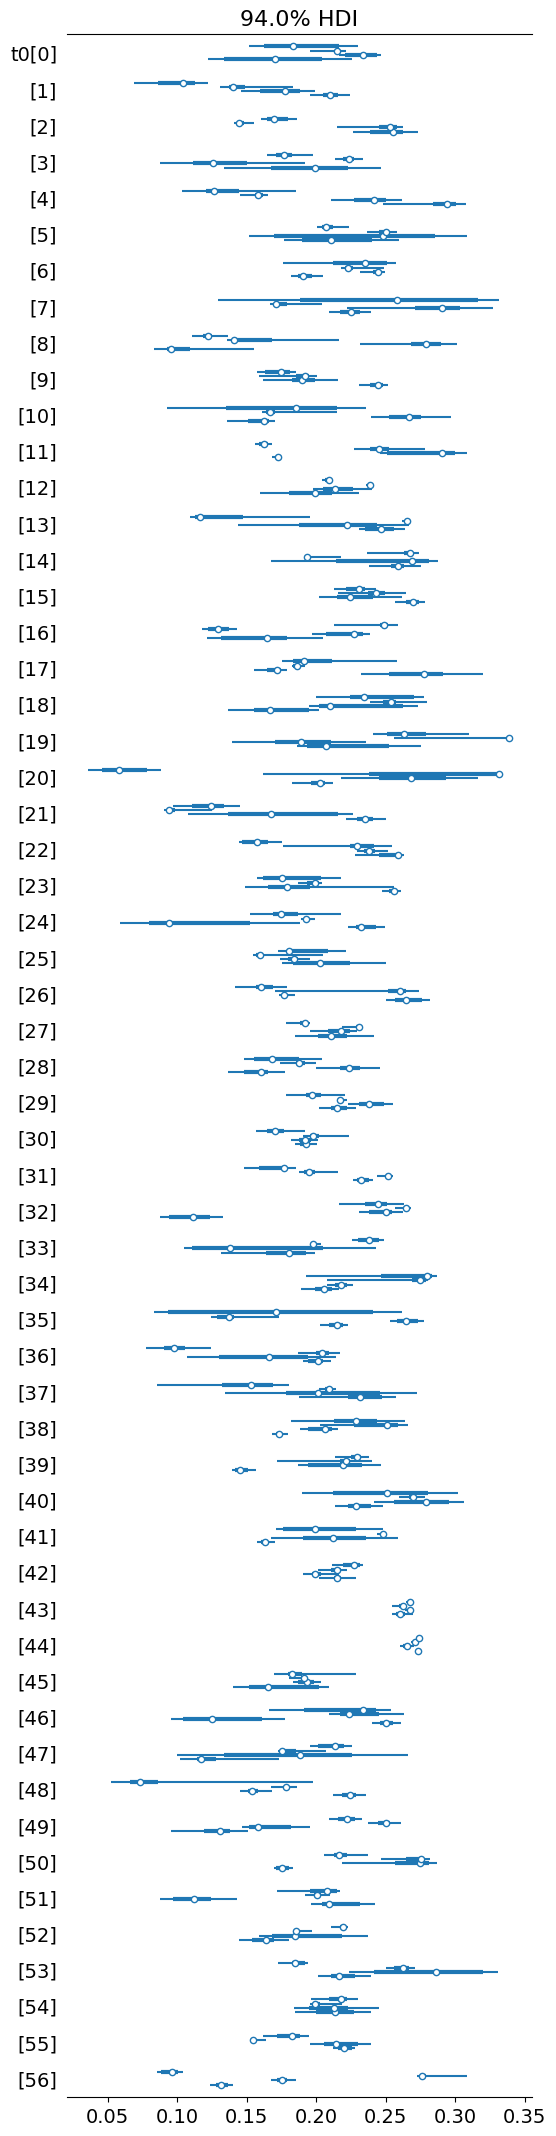

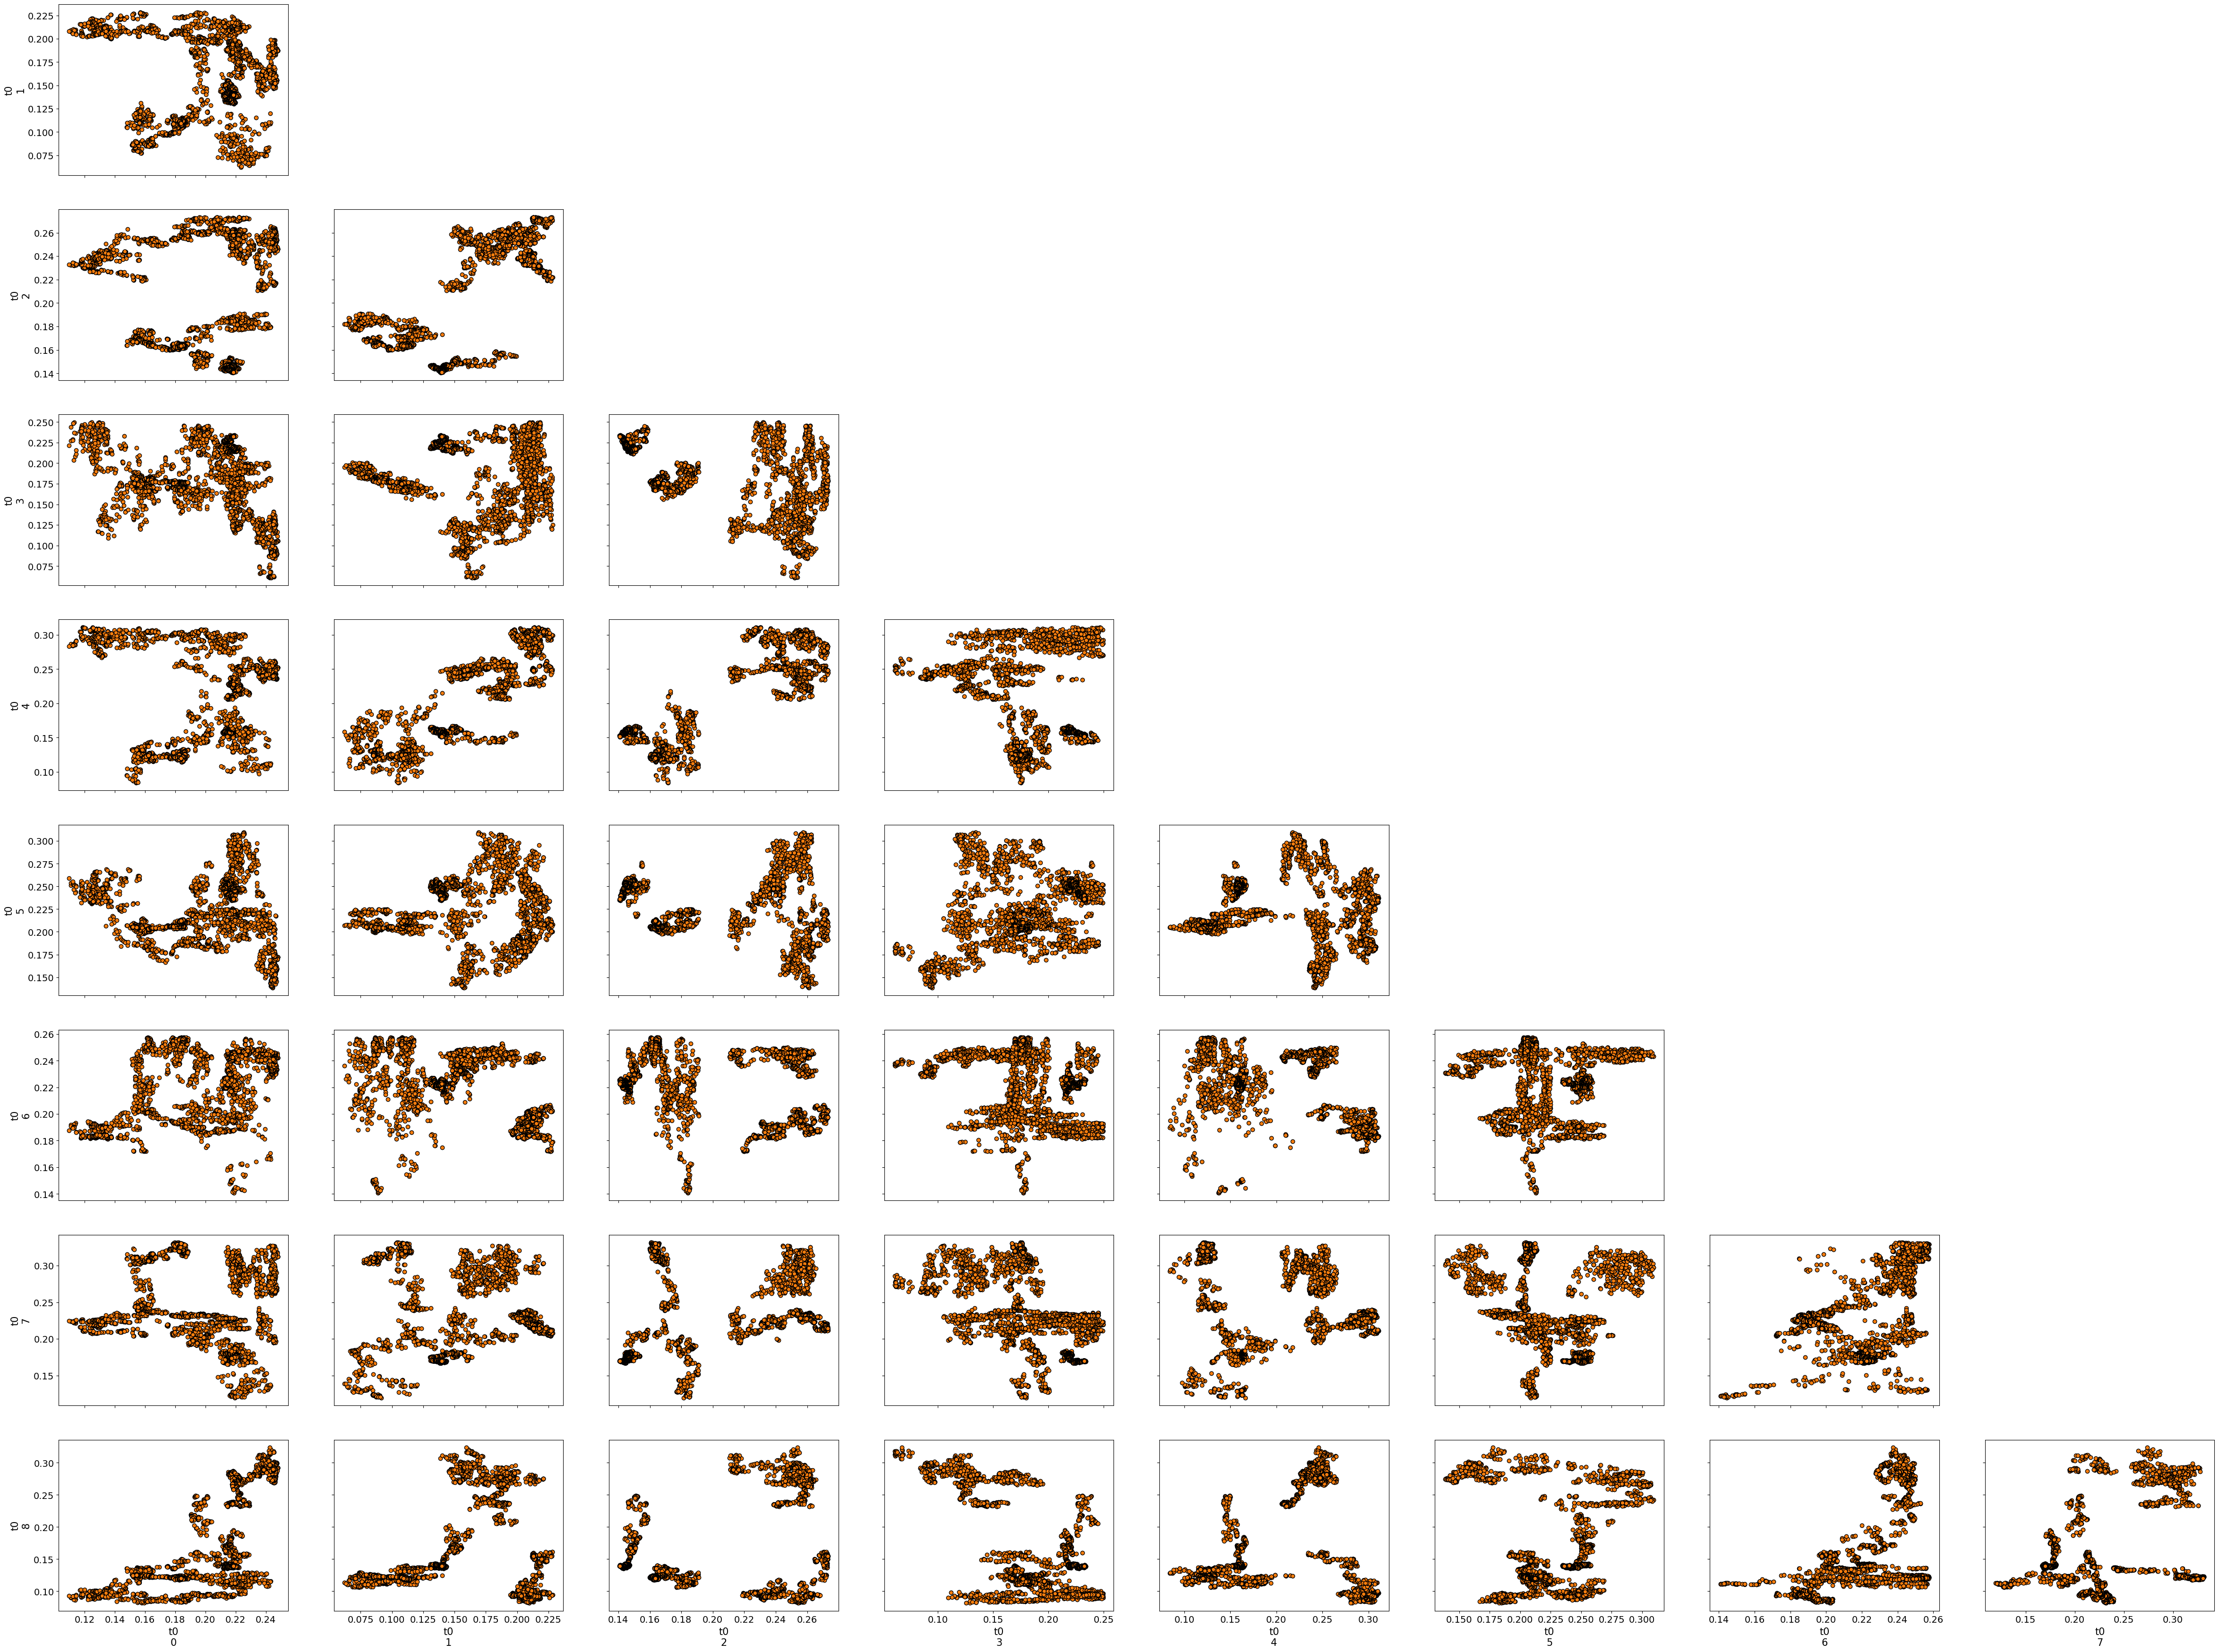

In [ ]:
import arviz as az

# CmdStanPy's fit object converts directly - ArviZ knows how to read it
idata = az.from_cmdstanpy(fit)

# posterior density + trace, per chain - the standard "did this converge" check
az.plot_trace(idata, var_names=["d", "r", "B", "p_lapse"])

# just the posterior distributions, no trace
az.plot_posterior(idata, var_names=["p_lapse"])

# compare a parameter across all P participants at once - useful given no pooling
az.plot_forest(idata, var_names=["t0"])

# check the t0 / p_lapse correlation we flagged earlier
az.plot_pair(idata, var_names=["t0", "p_lapse"], divergences=True)